In [1]:
%pip install matplotlib requests moviepy


# IsoNCA × LPPN — Report V2 experiment

Run all cells on CPU or GPU. The **live mechanics experiment** below tests the actual decoder classes on three new asymmetric states and a paired-mask IsoNCA path; it uses untrained weights and does not claim to reproduce the historical image-quality scores. The second part verifies and displays a compact extract from completed training studies. The PNGs are unchanged extracts; `evidence.json` contains selected metrics and marker-control per-history rows. Their hashes and sources are in `docs/assets/isonca_lppn/manifest.json`.

The notebook downloads the pinned lizard target if this checkout lacks it. No large checkpoints are required. The first cell installs the presentation dependencies; the setup cell installs PyTorch only if the runtime lacks it.


In [2]:
from pathlib import Path
import hashlib
import json
import statistics
import subprocess

import matplotlib.pyplot as plt
from PIL import Image
try:
    from IPython.display import Markdown, display
except ImportError:  # Also permit a plain Python smoke run.
    class Markdown(str):
        pass
    def display(value):
        print(value)

candidates = [Path.cwd(), Path.cwd().parent, Path('/workspace/Cells2Pixels'), Path('/content/Cells2Pixels')]
repo = next((p for p in candidates if (p / 'docs/assets/isonca_lppn/manifest.json').is_file()), None)
if repo is None:
    checkout = Path('/content/Cells2Pixels')
    if checkout.exists():
        raise FileNotFoundError('This checkout lacks the isotropic results assets; update the isotropic branch.')
    subprocess.run(['git', 'clone', '--depth', '1', '--branch', 'isotropic',
                    'https://github.com/IvanLudvig/Cells2Pixels.git', str(checkout)], check=True)
    repo = checkout
assets = repo / 'docs/assets/isonca_lppn'
manifest = json.loads((assets / 'manifest.json').read_text())
for name, info in manifest['files'].items():
    actual = hashlib.sha256((assets / name).read_bytes()).hexdigest()
    assert actual == info['sha256'], f'Asset hash mismatch: {name}'
evidence = json.loads((assets / 'evidence.json').read_text())
print('Verified', len(manifest['files']), 'evidence files in', assets)

def show_panel(filename, title, width=16):
    image = Image.open(assets / filename)
    plt.figure(figsize=(width, width * image.height / image.width))
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()


Verified 5 evidence files in /content/Cells2Pixels/docs/assets/isonca_lppn


## Live experiment: local decoder symmetry and paired stochastic dynamics

These fresh tests establish a **mechanics property**, using small random states and untrained weights. The archive panels farther below are the evidence for trained image quality. Numerical error may vary slightly with device and PyTorch version.

In [3]:
# Target bootstrap and the exact padded invariant-loss contract.
import importlib.util
import sys
if importlib.util.find_spec('torch') is None or importlib.util.find_spec('torchvision') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch', 'torchvision'], check=True)
import torch
import torch.nn.functional as F
import requests
from io import BytesIO

sys.path.insert(0, str(repo))
from losses.invariant_image_loss import InvariantImageLoss
from models.isonca import GradNormIsoGrowingNCA
from models.isotropic_lppn import IsotropicNeighborhoodLPPN
from models.siren import Siren
from utils.render import Renderer2D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGET_IMAGE_PATH = repo / 'data/morphology_png/lizard.png'
TARGET_URL = 'https://raw.githubusercontent.com/googlefonts/noto-emoji/43bac1a1272f31cedf0d74c2089fba6c7f952276/png/512/emoji_u1f98e.png'
if not TARGET_IMAGE_PATH.is_file():
    response = requests.get(TARGET_URL, headers={'User-Agent': 'Cells2Pixels Report V2'}, timeout=60)
    response.raise_for_status()
    Image.open(BytesIO(response.content)).verify()
    TARGET_IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)
    TARGET_IMAGE_PATH.write_bytes(response.content)
loss = InvariantImageLoss(
    target_path=str(TARGET_IMAGE_PATH), image_size=(256, 256), padding=(64, 64),
    premultiply_alpha=True, aux_type='binary', mirror=True, device=device)
assert tuple(loss.target_image.shape) == (1, 5, 384, 384)
print('Device:', device, '| padded target:', tuple(loss.target_image.shape[-2:]))


/content/Cells2Pixels/utils/icosphere.py:181: SyntaxWarning: invalid escape sequence '\ '
  indexing given by reading order             / \ / \
/content/Cells2Pixels/utils/icosphere.py:208: SyntaxWarning: invalid escape sequence '\ '
  first corners vertices, then on-edges       / \ / \
/content/Cells2Pixels/utils/icosphere.py:236: SyntaxWarning: invalid escape sequence '\ '
  given coordinates of the on-edge               / \ / \
/usr/local/lib/python3.13/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Device: cpu | padded target: (384, 384)


In [4]:
# Three fresh asymmetric probes; compare every decoder to its transformed output.
CHANNELS, SCALE, GRID = 8, 4, 16
names = ('interpolated_only', 'cartesian_coords', 'isotropic_neighbors', 'isotropic_neighbors_radial')
renderer = Renderer2D(scale_factor=SCALE, padding='circular', fs_shader='vanilla', precision=torch.float32)

def make_decoder(name):
    if name.startswith('isotropic_neighbors'):
        torch.manual_seed(2301)
        return IsotropicNeighborhoodLPPN(
            in_features=CHANNELS, out_features=4, scale_factor=SCALE,
            message_features=16, hidden_features=32,
            radial_distance=(name == 'isotropic_neighbors_radial')).to(device).eval()
    torch.manual_seed(2300)  # The Cartesian and no-coordinate SIRENs share weights.
    return Siren(
        in_features=CHANNELS, coord_dim=2, hidden_features=32,
        hidden_layers=1, out_features=4, outermost_linear=True,
        first_omega_0=10.0, hidden_omega_0=10.0,
        fx='linear', activation='sin', num_frequencies=1,
        disable=False, disable_coords=(name == 'interpolated_only')).to(device).eval()

def decode(name, decoder, state, neighbor_permutation=None):
    if name.startswith('isotropic_neighbors'):
        return decoder(state, neighbor_permutation=neighbor_permutation)
    return renderer.render(state.permute(0, 2, 3, 1), decoder, None,
                           fs_shader='vanilla', hard_clamp=False)

def transform_state(x, operation):
    if operation.startswith('rot'):
        return torch.rot90(x, int(operation[3:]) // 90, (-2, -1))
    return torch.flip(x, (-1,) if operation == 'flip_x' else (-2,))

def transform_image(x, operation):
    if operation.startswith('rot'):
        return torch.rot90(x, int(operation[3:]) // 90, (-3, -2))
    return torch.flip(x, (-2,) if operation == 'flip_x' else (-3,))

def relative_l2(actual, expected):
    return float(torch.linalg.vector_norm((actual - expected).reshape(-1)) /
                 torch.linalg.vector_norm(expected.reshape(-1)).clamp_min(1e-8))

operations = ('rot90', 'rot180', 'rot270', 'flip_x', 'flip_y')
decoders = {name: make_decoder(name) for name in names}
probes = [torch.randn(1, CHANNELS, GRID, GRID, device=device,
                      generator=torch.Generator(device=device).manual_seed(2400 + i))
          for i in range(3)]
live_decoder_rows = []
with torch.no_grad():
    for name, decoder in decoders.items():
        errors, permutation_errors = [], []
        for probe in probes:
            base = decode(name, decoder, probe)
            for operation in operations:
                actual = decode(name, decoder, transform_state(probe, operation))
                expected = transform_image(base, operation)
                errors.append(relative_l2(actual, expected))
            if name.startswith('isotropic_neighbors'):
                permuted = decode(name, decoder, probe, neighbor_permutation=[2, 0, 3, 1])
                permutation_errors.append(relative_l2(permuted, base))
        live_decoder_rows.append(dict(decoder=name, mean_relative_l2=statistics.mean(errors),
                                      max_relative_l2=max(errors),
                                      permutation_max=max(permutation_errors) if permutation_errors else None))
for row in live_decoder_rows:
    print(row['decoder'], '| mean D4', f"{row['mean_relative_l2']:.3e}",
          '| max D4', f"{row['max_relative_l2']:.3e}",
          '| permutation max', row['permutation_max'])
for row in live_decoder_rows:
    if row['decoder'] != 'cartesian_coords':
        assert row['max_relative_l2'] < 1e-4
        if row['permutation_max'] is not None:
            assert row['permutation_max'] < 1e-4


interpolated_only | mean D4 1.424e-07 | max D4 1.559e-07 | permutation max None
cartesian_coords | mean D4 5.694e-01 | max D4 6.536e-01 | permutation max None
isotropic_neighbors | mean D4 7.457e-08 | max D4 7.737e-08 | permutation max 5.58297514885453e-08
isotropic_neighbors_radial | mean D4 7.998e-08 | max D4 8.300e-08 | permutation max 5.588645990428631e-08


In [5]:
# Paired 90-degree path: rotate the state and every stochastic update mask.
torch.manual_seed(2500)
model = GradNormIsoGrowingNCA(channels=CHANNELS, fc_dim=32, padding='circular',
                              update_prob=0.5, device=device, precision=torch.float32).to(device).eval()
with torch.no_grad():
    torch.nn.init.normal_(model.w2.weight, std=0.003)  # Make the untrained path nontrivial.
    initial = torch.randn(1, CHANNELS, GRID, GRID, device=device) * 0.05
    initial[:, 3:4] = 0.5  # Living support throughout this mechanics probe.
    generator = torch.Generator(device=device).manual_seed(2501)
    masks = (torch.rand(12, 1, 1, GRID, GRID, device=device, generator=generator) < 0.5).float()
    base, rotated = initial.clone(), torch.rot90(initial, 1, (-2, -1))
    for mask in masks:
        base, _ = model(base, update_mask=mask)
        rotated, _ = model(rotated, update_mask=torch.rot90(mask, 1, (-2, -1)))
    state_error = relative_l2(rotated, torch.rot90(base, 1, (-2, -1)))
    change = float((base - initial).abs().max())
    live_path_rows = []
    for name, decoder in decoders.items():
        actual = decode(name, decoder, rotated)
        expected = torch.rot90(decode(name, decoder, base), 1, (-3, -2))
        live_path_rows.append(dict(decoder=name, render_relative_l2=relative_l2(actual, expected)))
print('State changed by', f'{change:.3e}', '| paired state D4 relative L2', f'{state_error:.3e}')
for row in live_path_rows:
    print(row['decoder'], '| paired render D4 relative L2', f"{row['render_relative_l2']:.3e}")
assert change > 1e-6 and state_error < 1e-4
for row in live_path_rows:
    if row['decoder'] != 'cartesian_coords':
        assert row['render_relative_l2'] < 1e-4

live_metrics = dict(device=str(device), torch=torch.__version__,
                    target_sha256=hashlib.sha256(TARGET_IMAGE_PATH.read_bytes()).hexdigest(),
                    probe_seeds=[2400, 2401, 2402], mask_seed=2501,
                    decoder_rows=live_decoder_rows,
                    path_state_relative_l2=state_error, path_change_max=change,
                    path_rows=live_path_rows)
output_path = Path.cwd() / 'isonca_lppn_report_v2_live_metrics.json'
output_path.write_text(json.dumps(live_metrics, indent=2) + '\n')
print('Saved live measurements to', output_path)


State changed by 7.033e-02 | paired state D4 relative L2 2.486e-08
interpolated_only | paired render D4 relative L2 1.273e-07
cartesian_coords | paired render D4 relative L2 6.521e-01
isotropic_neighbors | paired render D4 relative L2 6.113e-08
isotropic_neighbors_radial | paired render D4 relative L2 6.916e-08
Saved live measurements to /content/isonca_lppn_report_v2_live_metrics.json


## Archived training evidence

The following figures and metric rows were produced by the completed training studies, then selected for this concise report. The live untrained mechanics measurements above are separate evidence.

### Matched decoder comparison and padded baseline

The table reproduces the **decoder-only** relative L2 ranges from the original matched comparison. It uses one asymmetric probe state and lossless 90° rotations/reflections. These values do not measure arbitrary-angle isotropy. The image is a later padded `interpolated_only` result; its paired-mask render error is small, but the lizard remains soft.

| Decoder | Exact D4 relative L2 range |
|---|---:|
| Interpolated state only | 1.83e-07 to 2.07e-07 |
| Cartesian subcell coordinates | 2.77e-02 to 4.02e-02 |
| Unordered neighbors | 2.55e-07 to 2.81e-07 |
| Unordered neighbors + radius | 2.10e-07 to 2.30e-07 |


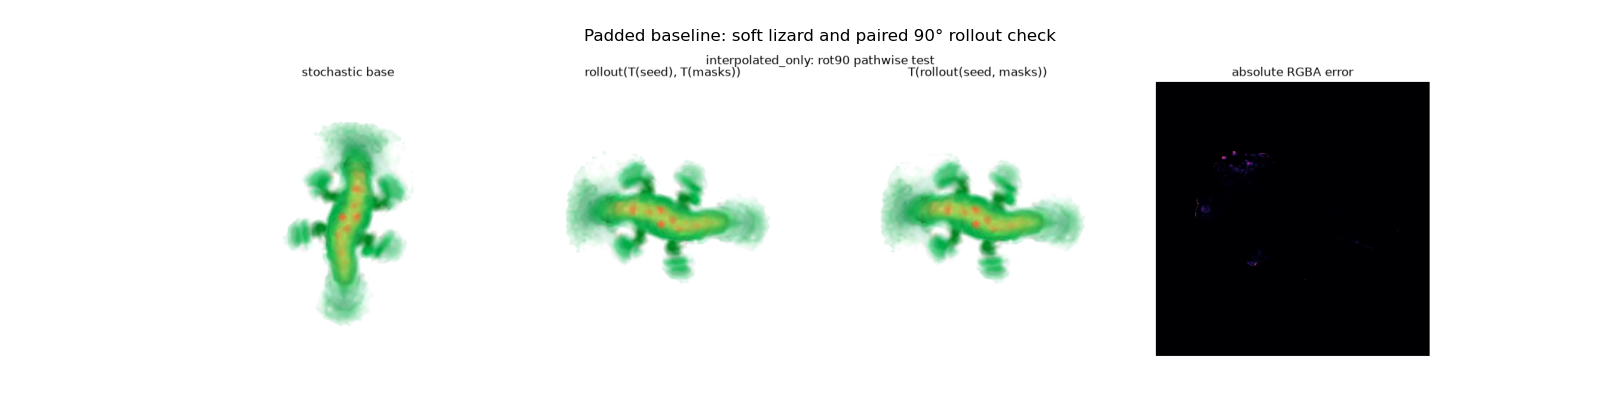

In [6]:
labels = [
    ('interpolated_only', 'Interpolated state only'),
    ('cartesian_coords', 'Cartesian subcell coordinates'),
    ('isotropic_neighbors', 'Unordered neighbors'),
    ('isotropic_neighbors_radial', 'Unordered neighbors + radius'),
]
rows = []
for key, label in labels:
    lo, hi = evidence['original_decoder_d4_relative_l2'][key]
    rows.append((label, f'{lo:.2e} to {hi:.2e}'))
display(Markdown('| Decoder | Exact D4 relative L2 range |\n|---|---:|\n' +
                 ''.join(f'| {name} | {value} |\n' for name, value in rows)))
show_panel('padded_baseline.png', 'Padded baseline: soft lizard and paired 90° rollout check')


### Frozen-state decoder control and learned isotropic growth

The frozen-state decoder study trains only the decoder on states from a **directional** NCA. The scalar-growth study uses a scalar Laplacian/gradient-norm IsoNCA and audits 16 independent trajectories. Both image-quality numbers use the same composite quality definition, but they are different trained systems. The frozen-state decoder D4 number is a decoder-only maximum absolute pixel error; the scalar-growth D4 number is a paired-path error.

| System | Age-128 audit quality ↓ | Symmetry measurement | Interpretation |
|---|---:|---:|---|
| Frozen-state decoder on directional NCA state | 0.017190 | decoder max abs 4.77e-07 | sharp capacity control |
| Scalar growth with D4 decoder | 0.559200 | paired-path max abs 2.12e-04 | near-radial growth |


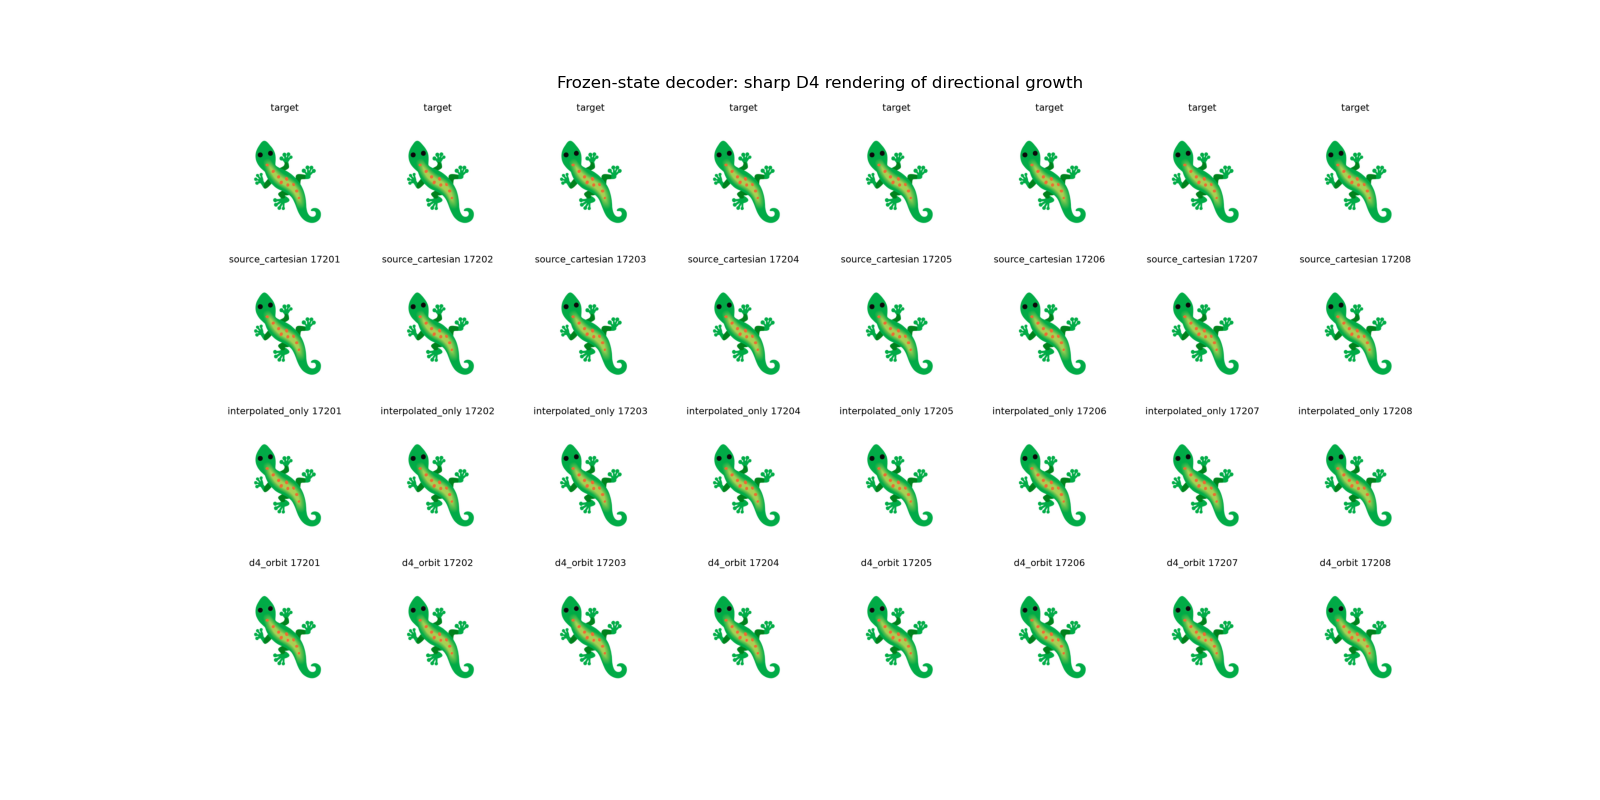

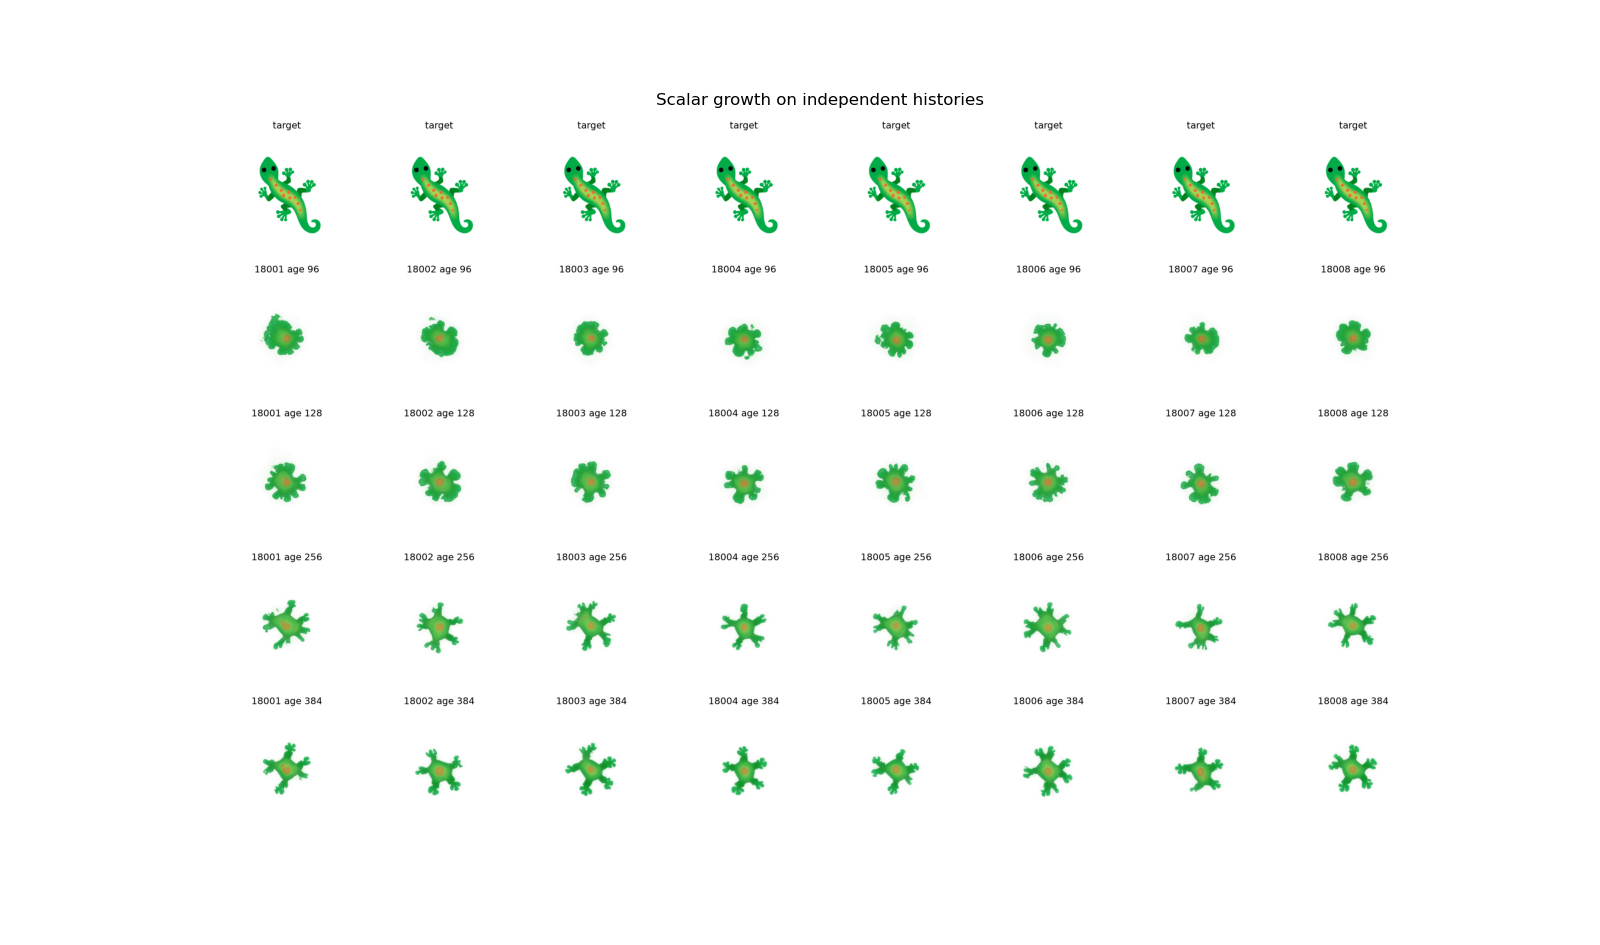

In [7]:
sharp = evidence['v17a']
isotropic = evidence['v17b3']
assert sharp['status'] == isotropic['status'] == 'complete'
display(Markdown(
    '| System | Age-128 audit quality ↓ | Symmetry measurement | Interpretation |\n'
    '|---|---:|---:|---|\n'
    f"| Frozen-state decoder on directional NCA state | {sharp['quality_mean']:.6f} | decoder max abs {sharp['readout_d4_max_abs']:.2e} | sharp capacity control |\n"
    f"| Scalar growth with D4 decoder | {isotropic['age128_quality_mean']:.6f} | paired-path max abs {isotropic['pathwise_d4_image_max_abs']:.2e} | near-radial growth |\n"
))
show_panel('frozen_state_decoder.png', 'Frozen-state decoder: sharp D4 rendering of directional growth')
show_panel('scalar_growth.png', 'Scalar growth on independent histories')


### Full-history scalar-marker control

The marker control compared gradients through the last 16 growth steps with gradients through all 64, plus a matched blank-seed full-history arm. Selection used one fixed mask history; the table computes new-history means from eight saved audit rows. Its fixed-pose loss is **not comparable** to the frozen-state decoder and scalar-growth quality scores.

| Arm | Fixed loss ↓ | Fresh age-64 loss ↓ | Fresh age-128 loss ↓ | Fresh age-64 axis ratio |
|---|---:|---:|---:|---:|
| Marker, last 16 steps | 0.188927 | 0.191805 | 0.507155 | 1.043 |
| Marker, all 64 steps | 0.187918 | 0.193774 | 3.775398 | 1.041 |
| Blank, all 64 steps | 0.187088 | 0.193511 | 1.747665 | 1.039 |

Target axis ratio: 2.262
Full-marker fresh ablation effect: 0.00814%
Registered decision: full_history_marker_mechanism_not_supported


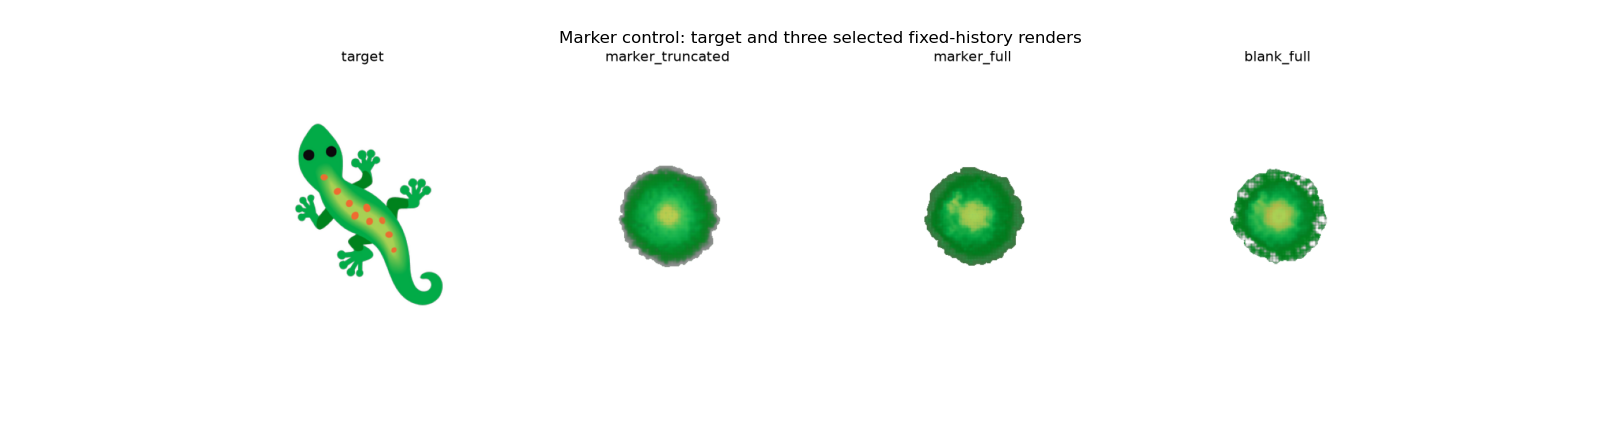

In [8]:
v49 = evidence['v49']
assert v49['status'] == 'complete'
labels = {'marker_truncated': 'Marker, last 16 steps',
          'marker_full': 'Marker, all 64 steps',
          'blank_full': 'Blank, all 64 steps'}
lines = []
for key, label in labels.items():
    audit = v49['arms'][key]
    fresh64 = statistics.mean(r['age64']['loss'] for r in audit['fresh'])
    fresh128 = statistics.mean(r['age128']['loss'] for r in audit['fresh'])
    axis64 = statistics.mean(r['age64']['axis_ratio'] for r in audit['fresh'])
    lines.append(f"| {label} | {audit['fixed']['loss']:.6f} | {fresh64:.6f} | {fresh128:.6f} | {axis64:.3f} |")
display(Markdown('| Arm | Fixed loss ↓ | Fresh age-64 loss ↓ | Fresh age-128 loss ↓ | Fresh age-64 axis ratio |\n'
                 '|---|---:|---:|---:|---:|\n' + '\n'.join(lines)))
print('Target axis ratio:', round(v49['target_axis_ratio'], 3))
print('Full-marker fresh ablation effect:', f"{100 * v49['fresh_marker_ablation']:.5f}%")
print('Registered decision:', v49['decision'])
show_panel('marker_control.png', 'Marker control: target and three selected fixed-history renders')


## Conclusion and scope

- The coordinate-free decoders show near-numerical **grid D4** symmetry in the selected tests; Cartesian local coordinates introduce a measurable orientation bias.
- Sharp appearance is possible from a suitable cellular state. The sharp frozen state was produced by a **directional** rule.
- The tested learned isotropic growth models did not combine a sharp, non-radial lizard with that symmetry. The marker control adds a negative causal result for one scalar-marker protocol.
- The early decoder study has one training seed per arm. The evidence covers one target, selected architectures, and finite audit banks. Arbitrary-angle isotropy remains unmeasured with a controlled resampling baseline.

See [`docs/isonca_lppn_results_v2.md`](../../docs/isonca_lppn_results_v2.md) for the short research report and the original executed-notebook references. The development history and large checkpoints are intentionally outside this branch.